In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('darkgrid')
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
""" Semilla """
seed = 99

## DATOS ##

data=pd.read_csv('SAheartbis.csv')

data['chd'] = data['chd'].map({'Si': 1, 'No': 0})

data = data.drop(columns=["Unnamed: 0"]) ## depende de la versión la exporta

y=pd.DataFrame(data["chd"])
X=data.drop(columns="chd")


[X_train, X_test, y_train, y_test] = train_test_split(X, y, test_size = 0.30, random_state = 101)


In [2]:
display(X_train.head())
display(y_train.head())

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,famhist_Present
93,-0.992806,0.079413,-0.382045,-0.829453,0.091375,-0.212423,-0.356351,0.423760,0
213,-0.309016,-0.792417,-1.817753,-0.516803,0.907127,0.167704,-0.696983,0.697861,0
278,-1.188175,-0.792417,-1.020138,-2.022154,-0.826346,-1.937250,-0.696983,-1.837577,0
225,0.228247,0.306089,0.057851,-0.233745,0.499251,-0.321709,0.068519,-0.055918,0
121,-0.895122,-0.487277,0.729782,-0.635172,0.703189,-0.046117,-0.348990,-1.015273,0


,chd
93,1
213,0
278,0
225,0
121,0


In [3]:

### MODELOS ##

models = []
models.append(('LR', LogisticRegression(random_state=seed)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('DTC', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('RFC', RandomForestClassifier(random_state=seed)))
models.append(('SVM', SVC(probability=True)))

###############

results = []
names = []
prediciones_train = []
prediccion_test = []
prediccion_train = []

#name='SVM'
#model=SVC(probability=True)
for name, model in models:

    pipeline = make_pipeline(model) ## en realidad no hacemos nada de pipeline pero lo dejo preparado
    pipeline.fit(X_train,y_train)
    aux_test=pipeline.predict_proba(X_test)[:,1] ## me quedo con la probabilidad del si
    aux_test=pd.DataFrame(aux_test, columns=[name])

    aux_train=pipeline.predict_proba(X_train)[:,1] ## me quedo con la probabilidad del si
    aux_train=pd.DataFrame(aux_train, columns=[name])


    prediccion_test.append(aux_test)
    prediccion_train.append(aux_train)

    accuracy=pipeline.score(X_test, y_test)
   # kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
   #cv_results = cross_val_score(pipeline, X, y, cv=kfold, scoring='accuracy')
    results.append(accuracy)
    names.append(name)
print('Resultados', results)
# Concatenar las predicciones originales
predicciones_test = pd.concat(prediccion_test, axis=1)
display(predicciones_test)

predicciones_train = pd.concat(prediccion_train, axis=1)
#display(clasificadores_originales_train)

Resultados [0.7050359712230215, 0.7266187050359713, 0.6330935251798561, 0.6762589928057554, 0.7482014388489209, 0.6690647482014388, 0.6834532374100719]


,LR,LDA,KNN,DTC,NB,RFC,SVM
0,0.495257,0.502592,0.2,0.0,0.544322,0.40,0.303295
1,0.063438,0.068819,0.0,0.0,0.002450,0.06,0.189402
2,0.103324,0.105140,0.0,0.0,0.002087,0.14,0.211211
3,0.329588,0.367912,0.2,1.0,0.924842,0.37,0.423384
4,0.715236,0.754218,1.0,1.0,0.990669,0.82,0.772558
...,...,...,...,...,...,...,...
134,0.189118,0.175924,0.6,0.0,0.067349,0.28,0.260518
135,0.052685,0.055114,0.0,0.0,0.001430,0.05,0.223329
136,0.114398,0.131053,0.0,0.0,0.006702,0.08,0.209947
137,0.413846,0.373042,0.2,0.0,0.348740,0.31,0.263504


In [ ]:
cv_results = []


for name, model in models:
  pipeline = make_pipeline(model)
  kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
  cv_result = cross_val_score(pipeline, X, y, cv=kfold, scoring='accuracy')
  cv_results.append(cv_result)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_result.mean(), cv_result.std())
  print(msg)
print('CV Resultados', cv_results)

LR: 0.724838 (0.056849)
LDA: 0.735661 (0.053981)
KNN: 0.620953 (0.080127)
DTC: 0.640333 (0.072479)
NB: 0.709806 (0.056626)
RFC: 0.662211 (0.065898)
SVM: 0.701156 (0.061835)
CV Resultados [array([0.81, 0.77, 0.76, 0.7 , 0.72, 0.72, 0.7 , 0.65, 0.8 , 0.63]), array([0.83, 0.77, 0.74, 0.7 , 0.72, 0.72, 0.72, 0.7 , 0.83, 0.65]), array([0.68, 0.68, 0.67, 0.7 , 0.57, 0.65, 0.5 , 0.5 , 0.72, 0.54]), array([0.81, 0.64, 0.7 , 0.65, 0.57, 0.61, 0.7 , 0.59, 0.57, 0.59]), array([0.77, 0.72, 0.8 , 0.74, 0.7 , 0.72, 0.67, 0.63, 0.74, 0.61]), array([0.68, 0.7 , 0.83, 0.63, 0.63, 0.61, 0.65, 0.61, 0.7 , 0.59]), array([0.7 , 0.77, 0.74, 0.72, 0.67, 0.74, 0.61, 0.65, 0.8 , 0.61])]


           LR       LDA       KNN       DTC        NB       RFC       SVM
LR   1.000000  0.996674  0.633952  0.472901  0.866567  0.600604  0.835951
LDA  0.996674  1.000000  0.629540  0.472589  0.875353  0.600718  0.840595
KNN  0.633952  0.629540  1.000000  0.574352  0.632706  0.662399  0.727316
DTC  0.472901  0.472589  0.574352  1.000000  0.421934  0.971963  0.636760
NB   0.866567  0.875353  0.632706  0.421934  1.000000  0.550672  0.816416
RFC  0.600604  0.600718  0.662399  0.971963  0.550672  1.000000  0.736135
SVM  0.835951  0.840595  0.727316  0.636760  0.816416  0.736135  1.000000


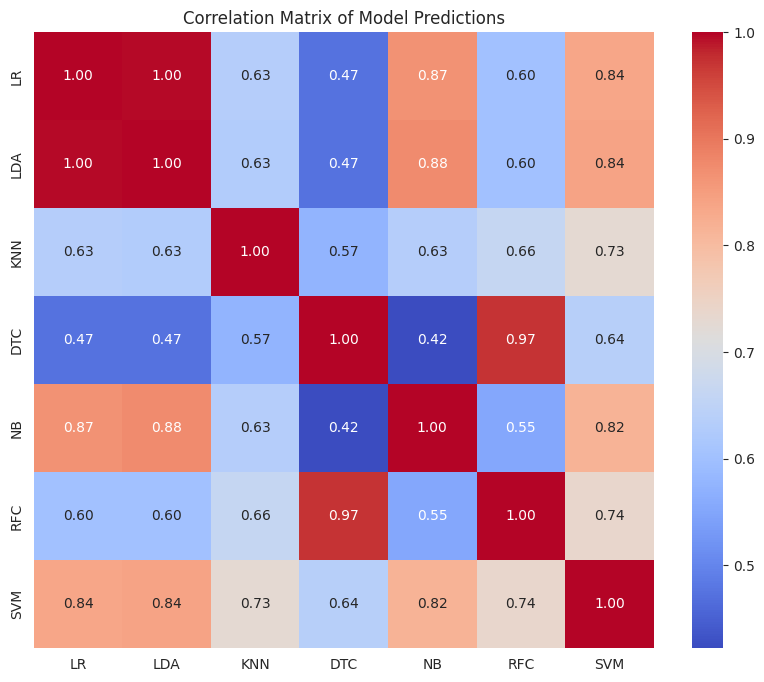

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Calculate the correlation matrix
correlation_matrix = predicciones_train.corr()

# Display the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Model Predictions')
plt.show()


GENERAR SIMPLEMENTE UN SISTEMA DE VOTACION !!!!!!

In [7]:
display(predicciones_test.head())

,LR,LDA,KNN,DTC,NB,RFC,SVM
0,0.495257,0.502592,0.2,0.0,0.544322,0.40,0.303295
1,0.063438,0.068819,0.0,0.0,0.002450,0.06,0.189402
2,0.103324,0.105140,0.0,0.0,0.002087,0.14,0.211211
3,0.329588,0.367912,0.2,1.0,0.924842,0.37,0.423384
4,0.715236,0.754218,1.0,1.0,0.990669,0.82,0.772558


from matplotlib import pyplot as plt
_df_0['LR'].plot(kind='hist', bins=20, title='LR')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['LDA'].plot(kind='hist', bins=20, title='LDA')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['KNN'].plot(kind='hist', bins=20, title='KNN')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['DTC'].plot(kind='hist', bins=20, title='DTC')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['DTC']
  ys = series['NB']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('DTC', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('DTC')
_ = plt.ylabel('NB')

from matplotlib import pyplot as plt
_df_12['LR'].plot(kind='line', figsize=(8, 4), title='LR')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['LDA'].plot(kind='line', figsize=(8, 4), title='LDA')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['KNN'].plot(kind='line', figsize=(8, 4), title='KNN')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['DTC'].plot(kind='line', figsize=(8, 4), title='DTC')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('knn', KNeighborsClassifier()),
        ('rf', RandomForestClassifier()),
        ('dtc_model' ,  DecisionTreeClassifier())
    ],
    voting='soft'
)



In [ ]:
# Entrenamiento
ensemble.fit(X_train, y_train)

# Evaluación
y_pred = ensemble.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del ensemble en Test: {accuracy:.4f}")

# Evaluación Train
y_pred = ensemble.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Accuracy del ensemble en Train: {accuracy:.4f}")


Accuracy del ensemble en Test: 0.6691
Accuracy del ensemble en Train: 0.9009


In [ ]:
## ha marecido la pena??

# Define the individual models
lr_model = LogisticRegression()
knn_model = KNeighborsClassifier()
dtc_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()

# List of models to evaluate
individual_models = [
    ('Logistic Regression', lr_model),
    ('K-Nearest Neighbors', knn_model),
    ('Random Forest', rf_model),
    ('Decision Tree', dtc_model)
]

# Train and evaluate each model
for name, model in individual_models:
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Print the results
    print(f"Accuracy de Test {name}: {accuracy:.4f}")


    # Calculate accuracy
    y_pred = model.predict(X_train)
    accuracy = accuracy_score(y_train, y_pred)

    # Print the results
    print(f"Accuracy de Train {name}: {accuracy:.4f}")



Accuracy de Test Logistic Regression: 0.7050
Accuracy de Train Logistic Regression: 0.7585
Accuracy de Test K-Nearest Neighbors: 0.6331
Accuracy de Train K-Nearest Neighbors: 0.7988
Accuracy de Test Random Forest: 0.6906
Accuracy de Train Random Forest: 1.0000
Accuracy de Test Decision Tree: 0.6835
Accuracy de Train Decision Tree: 1.0000


In [ ]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('knn', KNeighborsClassifier())

    ],
    voting='soft'
)


# Entrenamiento
ensemble.fit(X_train, y_train)

# Evaluación
y_pred = ensemble.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del ensemble en Test: {accuracy:.4f}")

# Evaluación Train
y_pred = ensemble.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Accuracy del ensemble en Train: {accuracy:.4f}")

Accuracy del ensemble en Test: 0.6906
Accuracy del ensemble en Train: 0.7957


COMO ME PUEDO FIAR DEL TRAIN !!!!! PARA ESO TENEMOS EL CV

In [ ]:
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
cv_result = cross_val_score(ensemble, X, y, cv=kfold, scoring='accuracy')
print("%f (%f)" % (cv_result.mean(), cv_result.std()))


0.683673 (0.075778)


VAMOS A COMBINAR LOS MODELOS !!!!!!!!!

In [ ]:
##esembles ####

### ensemble basico
## agregamos las probabilidades de los diferentes algoritmos para ver potencialmente

predicciones_test['ensemble1'] = (predicciones_test['LR'] + predicciones_test['LDA'])/2
predicciones_test['ensemble2'] = (predicciones_test['LR'] + predicciones_test['KNN'])/2
predicciones_test['ensemble3'] = (predicciones_test['LR'] + predicciones_test['DTC'])/2
predicciones_test['ensemble4'] = (predicciones_test['LR'] + predicciones_test['NB'])/2
predicciones_test['ensemble5'] = (predicciones_test['LR'] + predicciones_test['RFC'])/2
predicciones_test['ensemble6'] = (predicciones_test['LR'] + predicciones_test['SVM'])/2
predicciones_test['ensemble7'] = (predicciones_test['KNN'] + predicciones_test['RFC'] +  predicciones_test['SVM'])/3


# Select the relevant columns for the calculation
original_models = ['LR', 'LDA', 'KNN', 'DTC', 'NB', 'RFC', 'SVM']

# Calculate the maximum and minimum values for each row
predicciones_test['ensemble8'] = predicciones_test[original_models].max(axis=1)
predicciones_test['ensemble9'] = predicciones_test[original_models].min(axis=1)



In [ ]:
display(predicciones_test.head())

,LR,LDA,KNN,DTC,NB,RFC,SVM,ensemble1,ensemble2,ensemble3,ensemble4,ensemble5,ensemble6,ensemble7,ensemble8,ensemble9
0,0.495257,0.502592,0.2,0.0,0.544322,0.40,0.307950,0.498925,0.347628,0.247628,0.519789,0.447628,0.401604,0.449176,0.544322,0.000000
1,0.063438,0.068819,0.0,0.0,0.002450,0.06,0.200137,0.066129,0.031719,0.031719,0.032944,0.061719,0.131788,0.088675,0.200137,0.000000
2,0.103324,0.105140,0.0,0.0,0.002087,0.14,0.221083,0.104232,0.051662,0.051662,0.052705,0.121662,0.162203,0.108831,0.221083,0.000000
3,0.329588,0.367912,0.2,1.0,0.924842,0.37,0.419269,0.348750,0.264794,0.664794,0.627215,0.349794,0.374429,0.557900,1.000000,0.200000
4,0.715236,0.754218,1.0,1.0,0.990669,0.82,0.748590,0.734727,0.857618,0.857618,0.852952,0.767618,0.731913,0.818165,1.000000,0.715236


In [ ]:

predicciones_test['y_test'] = y_test.iloc[:, 0].values  # Usar .values para evitar problemas de índice

display(predicciones_test)






,LR,LDA,KNN,DTC,NB,RFC,SVM,ensemble1,ensemble2,ensemble3,ensemble4,ensemble5,ensemble6,ensemble7,ensemble8,ensemble9,y_test
0,0.495257,0.502592,0.2,0.0,0.544322,0.40,0.295968,0.498925,0.347628,0.247628,0.519789,0.447628,0.395613,0.298656,0.544322,0.000000,1
1,0.063438,0.068819,0.0,0.0,0.002450,0.06,0.172463,0.066129,0.031719,0.031719,0.032944,0.061719,0.117951,0.077488,0.172463,0.000000,0
2,0.103324,0.105140,0.0,0.0,0.002087,0.14,0.195508,0.104232,0.051662,0.051662,0.052705,0.121662,0.149416,0.111836,0.195508,0.000000,0
3,0.329588,0.367912,0.2,1.0,0.924842,0.37,0.431072,0.348750,0.264794,0.664794,0.627215,0.349794,0.380330,0.333691,1.000000,0.200000,1
4,0.715236,0.754218,1.0,1.0,0.990669,0.82,0.810071,0.734727,0.857618,0.857618,0.852952,0.767618,0.762654,0.876690,1.000000,0.715236,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.189118,0.175924,0.6,0.0,0.067349,0.28,0.248764,0.182521,0.394559,0.094559,0.128233,0.234559,0.218941,0.376255,0.600000,0.000000,0
135,0.052685,0.055114,0.0,0.0,0.001430,0.05,0.208458,0.053900,0.026343,0.026343,0.027058,0.051343,0.130572,0.086153,0.208458,0.000000,0
136,0.114398,0.131053,0.0,0.0,0.006702,0.08,0.194162,0.122726,0.057199,0.057199,0.060550,0.097199,0.154280,0.091387,0.194162,0.000000,0
137,0.413846,0.373042,0.2,0.0,0.348740,0.31,0.252033,0.393444,0.306923,0.206923,0.381293,0.361923,0.332939,0.254011,0.413846,0.000000,0


In [ ]:
#Resultados_finales = Resultados_finales.drop(columns=['y_test']) ## ahora la quito para binarizar

Resultados_finales=predicciones_test.drop(columns=['y_test'])

from sklearn.preprocessing import Binarizer

transformer = Binarizer(threshold=0.5).fit(Resultados_finales)  # fit does nothing.
predicciones_ensemble=pd.DataFrame(transformer.transform(Resultados_finales))

predicciones_ensemble['y_test'] = y_test.iloc[:, 0].values  # Usar .values para evitar problemas de índice

display(predicciones_ensemble)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,y_test
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
## ponemos el test solo para ver que esta ocurriendo

In [ ]:


# Calculamos las curvas ROC y accuracy de los ensembles

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

y_test.replace(('Si', 'No'), (1, 0), inplace=True)

accuracy_esemble=[]

for k in range(17):
  cm = confusion_matrix(y_test.iloc[:,0], predicciones_ensemble.iloc[:,k])
  accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
 # print('La precision para el clasificador' ,k+1, 'es', accuracy )
  print('El area bajo la curva para clasificador es' , k+1, 'es', roc_auc_score(y_test, predicciones_ensemble.iloc[:,k]))
  accuracy_esemble.append(accuracy)

#accuracy_esemble = pd.concat(accuracy_esemble, axis=1)
display(accuracy_esemble)


El area bajo la curva para clasificador es 1 es 0.6421676173760421
El area bajo la curva para clasificador es 2 es 0.670469504168495
El area bajo la curva para clasificador es 3 es 0.5804080737165423
El area bajo la curva para clasificador es 4 es 0.6478718736287845
El area bajo la curva para clasificador es 5 es 0.7277314611671786
El area bajo la curva para clasificador es 6 es 0.6094778411584028
El area bajo la curva para clasificador es 7 es 0.6080517770952172
El area bajo la curva para clasificador es 8 es 0.6610355419043441
El area bajo la curva para clasificador es 9 es 0.6305397103992979
El area bajo la curva para clasificador es 10 es 0.6478718736287845
El area bajo la curva para clasificador es 11 es 0.7132514260640631
El area bajo la curva para clasificador es 12 es 0.63635366388767
El area bajo la curva para clasificador es 13 es 0.63635366388767
El area bajo la curva para clasificador es 14 es 0.6530276437033787
El area bajo la curva para clasificador es 15 es 0.72762176393

[np.float64(0.7050359712230215),
 np.float64(0.7266187050359713),
 np.float64(0.6330935251798561),
 np.float64(0.6762589928057554),
 np.float64(0.7482014388489209),
 np.float64(0.6690647482014388),
 np.float64(0.6762589928057554),
 np.float64(0.7194244604316546),
 np.float64(0.6906474820143885),
 np.float64(0.6762589928057554),
 np.float64(0.7482014388489209),
 np.float64(0.697841726618705),
 np.float64(0.697841726618705),
 np.float64(0.7050359712230215),
 np.float64(0.7122302158273381),
 np.float64(0.6330935251798561),
 np.float64(1.0)]

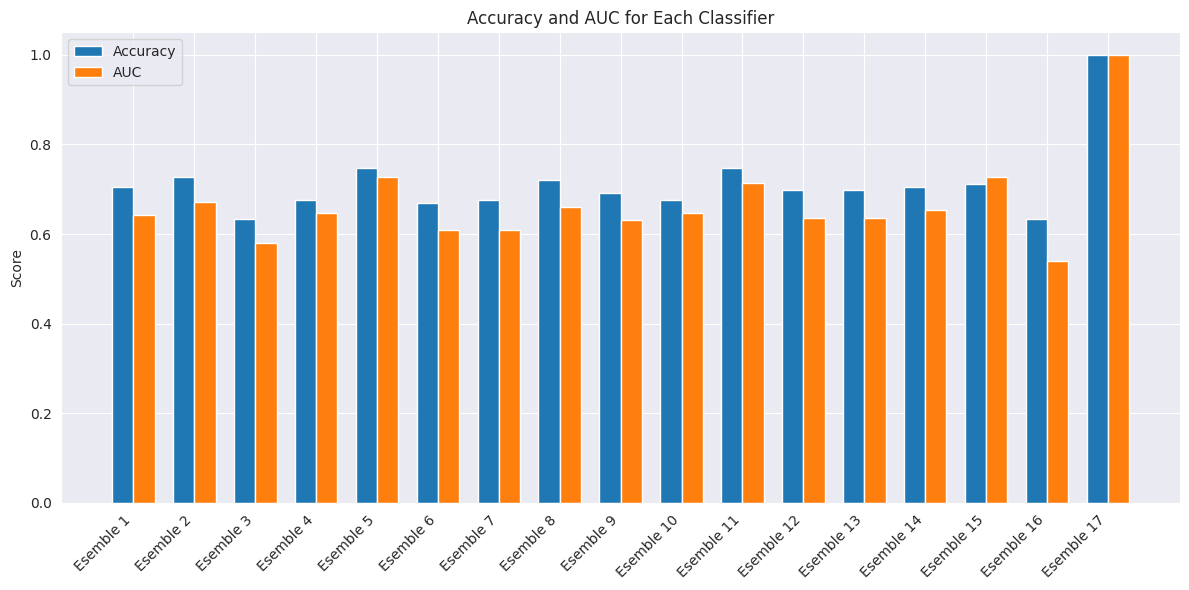

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a list to store AUC scores
roc_auc_scores = []
accuracy_esemble = [] # También asegúrate de inicializar accuracy_esemble

for k in range(16):
  cm = confusion_matrix(y_test.iloc[:,0], predicciones_ensemble.iloc[:,k])
  accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
  roc_auc = roc_auc_score(y_test, predicciones_ensemble.iloc[:,k])

  accuracy_esemble.append(accuracy)
  roc_auc_scores.append(roc_auc)

# Create labels for the bars
labels = [f'Esemble {i+1}' for i in range(17)]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, accuracy_esemble, width, label='Accuracy')
rects2 = ax.bar(x + width/2, roc_auc_scores, width, label='AUC')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Accuracy and AUC for Each Classifier')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()